# 文献约束的单液滴电场模型

## tl;dr
下面直接计算同净电荷球壳/体电荷、严格中性双电层与有限厚度偶极层的径向电场。文献数值与适用环境见 `../data/literature_parameters.csv`。

## Context & Methods

以半径 50 μm 的水滴为基准；局域探针场与远程 Coulomb 场分别参数化。参考 [JCP 2020](https://doi.org/10.1063/5.0006550)、[JPCL 2020](https://doi.org/10.1021/acs.jpclett.0c02061)、[Nature Communications 2022](https://doi.org/10.1038/s41467-021-27941-x) 和 [2024](https://doi.org/10.1038/s41467-024-47879-0)。

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import droplet_shadow
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [2]:
from droplet_shadow import SimulationConfig, build_field
from droplet_shadow.fields import rayleigh_charge_e
from droplet_shadow.config import Charge
base = SimulationConfig().with_updates(charge={'q_e': 1e7})
print(f'M={base.geometry.magnification:.1f}, Q/Q_R={1e7/rayleigh_charge_e(base.geometry.radius_m, 0.072):.3f}')

M=51.0, Q/Q_R=0.226


## Results

### 同净电荷分布的内外场

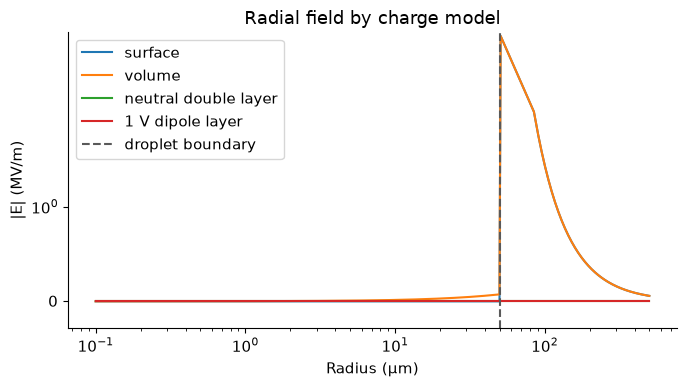

In [3]:
r_um = np.geomspace(0.1, 500, 500)
points = np.column_stack((r_um * 1e-6, np.zeros_like(r_um), np.zeros_like(r_um)))
models = {'surface': base, 'volume': base.with_updates(charge={'model': 'volume'}),
          'neutral double layer': base.with_updates(charge={'model': 'neutral_double_layer', 'q_e': 0, 'double_layer_q_e': 1e8}),
          '1 V dipole layer': base.with_updates(charge={'model': 'surface', 'q_e': 0, 'dipole_potential_v': 1.0})}
fig, ax = plt.subplots()
for name, cfg in models.items():
    f = build_field(cfg)
    ax.plot(r_um, abs(f.electric_field(points)[:, 0]) / 1e6, label=name)
ax.axvline(50, color='0.35', linestyle='--', label='droplet boundary')
ax.set(xscale='log', yscale='symlog', xlabel='Radius (μm)', ylabel='|E| (MV/m)', title='Radial field by charge model')
ax.legend(); fig.tight_layout(); plt.show()

### 守恒离子数的球对称 Poisson–Boltzmann 解

External E for neutral PB (V/m): 0.0


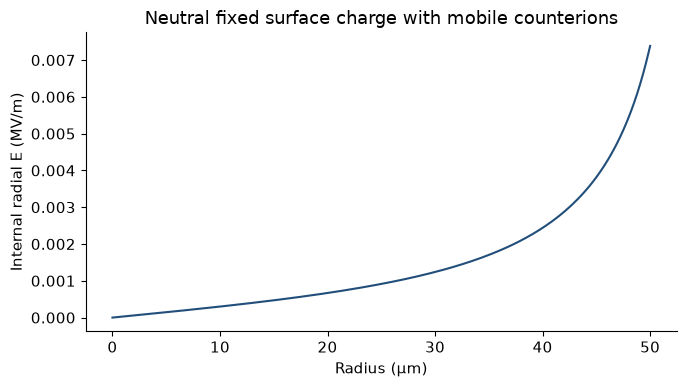

In [4]:
from droplet_shadow.fields import poisson_boltzmann
neutral = base.with_updates(charge={'model':'poisson_boltzmann', 'q_e':0, 'surface_fixed_e':-1e6, 'ion_positive_count':1e6})
pb = poisson_boltzmann(neutral)
print('External E for neutral PB (V/m):', pb.electric_field(np.array([[100e-6,0,0]]))[0,0])
fig, ax = plt.subplots()
ax.plot(pb.radii_m * 1e6, pb.field_v_m / 1e6, color='#214e7a')
ax.set(xlabel='Radius (μm)', ylabel='Internal radial E (MV/m)', title='Neutral fixed surface charge with mobile counterions')
fig.tight_layout(); plt.show()

## Takeaways

相同总电荷的球对称电荷模型具有相同外场；严格中性、完整同心的界面层没有外场。穿滴电子仍可能感受到内部场与材料散射。这里的连续介质场不等于单个分子键方向的瞬时场。